In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("Gold Price.csv")

df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')
df.set_index('Date', inplace=True)

df.head()
df.tail()
df.info()



<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3104 entries, 2014-01-01 to 2026-01-02
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Price   3104 non-null   int64  
 1   Open    3104 non-null   int64  
 2   High    3104 non-null   int64  
 3   Low     3104 non-null   int64  
 4   Volume  3104 non-null   int64  
 5   Chg%    3104 non-null   float64
dtypes: float64(1), int64(5)
memory usage: 169.8 KB


In [41]:
print(df.columns)


Index(['Price', 'Open', 'High', 'Low', 'Volume', 'Chg%'], dtype='object')


In [42]:
df.reset_index(inplace=True)
df.rename(columns={'index': 'Date'}, inplace=True)


In [43]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df = df.dropna(subset=['Date'])
df = df.sort_values('Date')
df.set_index('Date', inplace=True) # Set 'Date' as index after cleaning and sorting

In [44]:
print(df.index.min())
print(df.index.max())

2014-01-01 00:00:00
2026-01-02 00:00:00


In [67]:
# Create the primary target (future Close price)
df['Target_Close'] = df['Close'].shift(-1)
# Create future volatility and regime targets
df['Target_Volatility'] = df['Volatility'].shift(-1)
df['Target_Regime'] = df['Regime'].shift(-1)

# Drop any rows where features or the new target are NaN
df.dropna(inplace=True)

In [45]:
# Rename for financial convention
df.rename(columns={'Price': 'Close'}, inplace=True)

# Convert Chg% to float (if not already)
df['Chg%'] = df['Chg%'].astype(float)

# This line was creating an artificial index, causing a date mismatch.
# Removed: df.index = pd.date_range(start='2000-01-01', periods=len(df), freq='D')

df.head()

,Close,Open,High,Low,Volume,Chg%
Date,,,,,,
2014-01-01,29542,29435,29598,29340,2930,0.25
2014-01-02,29975,29678,30050,29678,3140,1.47
2014-01-03,29727,30031,30125,29539,3050,-0.83
2014-01-04,29279,29279,29279,29279,0,-1.51
2014-01-06,29119,29300,29395,29051,24380,-0.55


#Feature Engineering (Regime-Sensitive)

In [46]:
# Log returns
df['Log_Return'] = np.log(df['Close'] / df['Close'].shift(1))

# Volatility (rolling)
df['Volatility'] = df['Log_Return'].rolling(14).std()

# Technical indicators
df['MA_10'] = df['Close'].rolling(10).mean()
df['MA_30'] = df['Close'].rolling(30).mean()

# Price range pressure
df['HL_Range'] = df['High'] - df['Low']
df['OC_Change'] = df['Open'] - df['Close']

df.dropna(inplace=True)


# VOLATILITY-AWARE TARGET

In [61]:
# Log returns
df['Return'] = np.log(df['Close'] / df['Close'].shift(1))

# Rolling volatility (20-day window)
df['Volatility'] = df['Return'].rolling(window=20).std()

df.dropna(inplace=True)

#Market Regime Detection (NOVEL)

In [47]:
from sklearn.cluster import KMeans

vol = df[['Volatility']]

#kmeans = KMeans(n_clusters=2, random_state=42)
#df['Regime'] = kmeans.fit_predict(vol)
# Market regime: 0 = calm, 1 = volatile
df['Regime'] = (df['Volatility'] > df['Volatility'].median()).astype(int)

# Label regimes
df['Regime_Label'] = df['Regime'].map({0: 'Low Volatility', 1: 'High Volatility'})


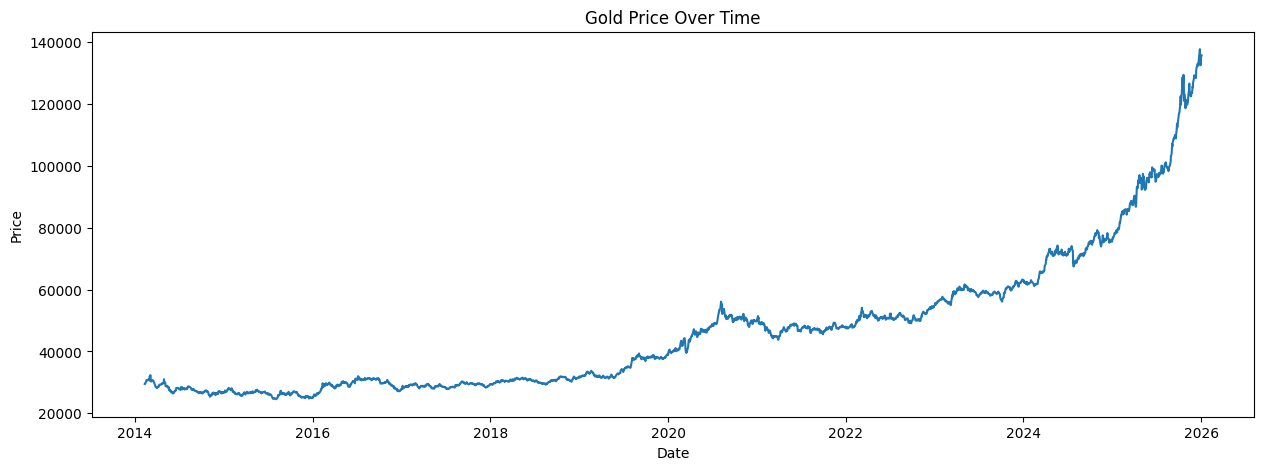

In [48]:
plt.figure(figsize=(15,5))
plt.plot(df.index, df['Close'])
plt.title('Gold Price Over Time')
plt.xlabel('Date')
plt.ylabel('Price')
plt.show()

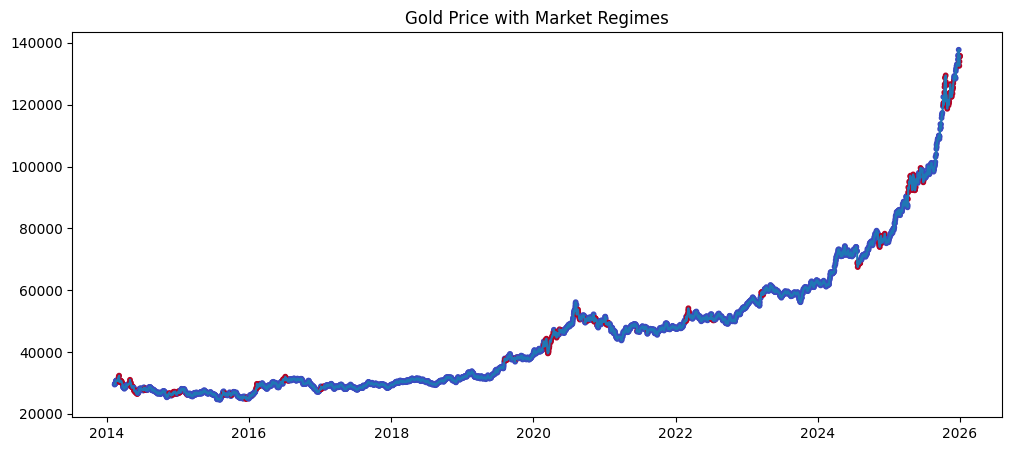

In [49]:
plt.figure(figsize=(12,5))
plt.plot(df.index, df['Close'], label='Gold Price')
plt.scatter(df.index, df['Close'], c=df['Regime'], cmap='coolwarm', s=10)
plt.title("Gold Price with Market Regimes")
plt.show()




# Scaling + Sequence Creation



In [68]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

features = ['Close', 'Open', 'High', 'Low', 'Volume', 'Volatility', 'Regime']

# Define the target features
target_feature_price = 'Target_Close'
target_feature_volatility = 'Target_Volatility'
target_feature_regime = 'Target_Regime'

# Create separate scalers for features (X) and targets (y)
scaler_X = MinMaxScaler()
scaled_X = scaler_X.fit_transform(df[features])

scaler_y_price = MinMaxScaler()
scaled_y_price = scaler_y_price.fit_transform(df[[target_feature_price]])

scaler_y_volatility = MinMaxScaler()
scaled_y_volatility = scaler_y_volatility.fit_transform(df[[target_feature_volatility]])

scaler_y_regime = MinMaxScaler()
scaled_y_regime = scaler_y_regime.fit_transform(df[[target_feature_regime]])

def create_sequences(X_data, y_price_data, y_vol_data, y_reg_data, window=30):
    Xs, Yp, Yv, Yr = [], [], [], []
    for i in range(len(X_data) - window):
        Xs.append(X_data[i : i + window])
        Yp.append(y_price_data[i + window])
        Yv.append(y_vol_data[i + window])
        Yr.append(y_reg_data[i + window])
    return np.array(Xs), np.array(Yp), np.array(Yv), np.array(Yr)

X, y_price, y_vol, y_reg = create_sequences(
    scaled_X, scaled_y_price, scaled_y_volatility, scaled_y_regime, window=30
)

# Multi-head Attention LSTM

In [69]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Attention

input_layer = Input(shape=(X.shape[1], X.shape[2]))

lstm = LSTM(64, return_sequences=True)(input_layer)
attn = Attention()([lstm, lstm])

shared = Dense(32, activation='relu')(attn[:, -1, :])

price_out = Dense(1, name='price')(shared)
vol_out = Dense(1, name='volatility')(shared)
regime_out = Dense(1, activation='sigmoid', name='regime')(shared)

model = Model(inputs=input_layer, outputs=[price_out, vol_out, regime_out])

model.compile(
    optimizer='adam',
    loss={
        'price': 'mse',
        'volatility': 'mse',
        'regime': 'binary_crossentropy'
    }
)

model.summary()

# Define split ratio (e.g., 80% for training, 20% for validation)
split_ratio = 0.8
split_index = int(len(X) * split_ratio)

# Split features and targets into training and validation sets
X_train, X_val = X[:split_index], X[split_index:]
y_price_train, y_price_val = y_price[:split_index], y_price[split_index:]
y_vol_train, y_vol_val = y_vol[:split_index], y_vol[split_index:]
y_reg_train, y_reg_val = y_reg[:split_index], y_reg[split_index:]

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 30, 7)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_7 (LSTM)       │ (None, 30, 64)    │     18,432 │ input_layer_7[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_5         │ (None, 30, 64)    │          0 │ lstm_7[0][0],     │
│ (Attention)         │                   │            │ lstm_7[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 64)        │          0 │ attention_5[0][0] │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 32)        │      2,080 │ get_item_1[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ price (Dense)       │ (None, 1)         │         33 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ volatility (Dense)  │ (None, 1)         │         33 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ regime (Dense)      │ (None, 1)         │         33 │ dense_5[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 20,611 (80.51 KB)

 Trainable params: 20,611 (80.51 KB)

 Non-trainable params: 0 (0.00 B)

In [70]:
model.fit(
    X_train,
    {'price': y_price_train, 'volatility': y_vol_train, 'regime': y_reg_train},
    validation_data=(
        X_val,
        {'price': y_price_val, 'volatility': y_vol_val, 'regime': y_reg_val}
    ),
    epochs=30,
    batch_size=32
)

Epoch 1/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.6199 - price_loss: 0.0095 - regime_loss: 0.5653 - volatility_loss: 0.0450 - val_loss: 0.5523 - val_price_loss: 0.0387 - val_regime_loss: 0.4925 - val_volatility_loss: 0.0253
Epoch 2/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.3437 - price_loss: 0.0017 - regime_loss: 0.3301 - volatility_loss: 0.0118 - val_loss: 0.3451 - val_price_loss: 0.0329 - val_regime_loss: 0.3074 - val_volatility_loss: 0.0113
Epoch 3/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.2533 - price_loss: 0.0041 - regime_loss: 0.2393 - volatility_loss: 0.0098 - val_loss: 0.3131 - val_price_loss: 0.0184 - val_regime_loss: 0.2838 - val_volatility_loss: 0.0157
Epoch 4/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.2130 - price_loss: 0.0011 - regime_loss: 0.2042 - volatility_loss: 0.0077 - val_loss: 0.2376 - val_price_loss: 0.0082 - val_regime_loss: 0.2215 - val_volatility_loss: 0.0124
Epoch 5/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0

In [71]:
from sklearn.model_selection import train_test_split

X_train, X_val, \
y_price_train, y_price_val, \
y_vol_train, y_vol_val, \
y_reg_train, y_reg_val = train_test_split(
    X, y_price, y_vol, y_reg,
    test_size=0.2,
    shuffle=False
)


In [72]:
pred_price, pred_vol, pred_reg = model.predict(X_val)


19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


In [73]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_price_val, pred_price)
rmse = np.sqrt(mean_squared_error(y_price_val, pred_price))

print(f"Price MAE  : {mae:.4f}")
print(f"Price RMSE : {rmse:.4f}")


Price MAE  : 0.0677
Price RMSE : 0.1372


In [74]:
vol_mae = mean_absolute_error(y_vol_val, pred_vol)
print(f"Volatility MAE : {vol_mae:.4f}")


Volatility MAE : 0.0681


In [75]:
from sklearn.metrics import accuracy_score, classification_report

reg_pred = (pred_reg > 0.5).astype(int)

print("Regime Accuracy:", accuracy_score(y_reg_val, reg_pred))
print(classification_report(y_reg_val, reg_pred))


Regime Accuracy: 0.9367720465890182
              precision    recall  f1-score   support

         0.0       0.94      0.99      0.96       476
         1.0       0.93      0.75      0.83       125

    accuracy                           0.94       601
   macro avg       0.93      0.87      0.90       601
weighted avg       0.94      0.94      0.93       601



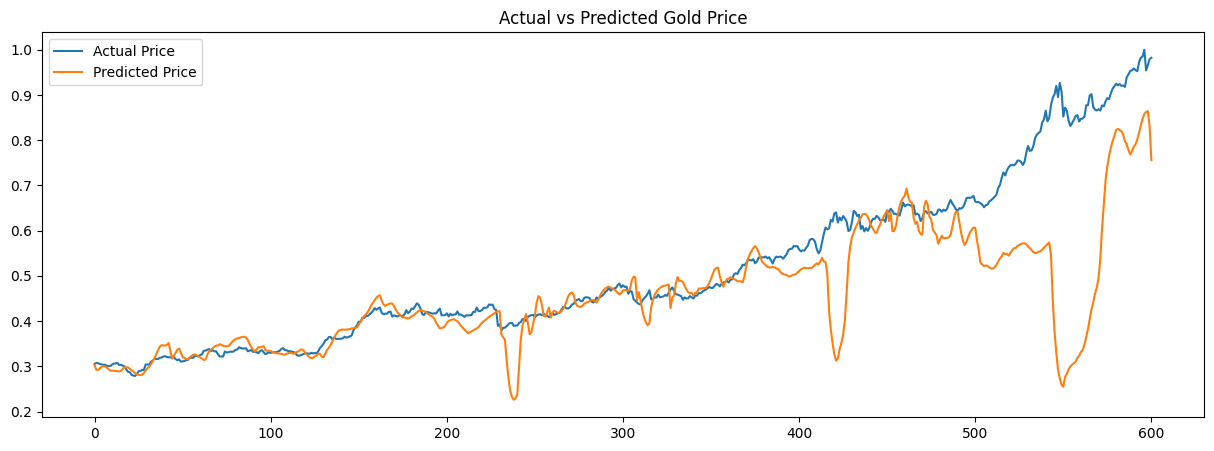

In [76]:
plt.figure(figsize=(15,5))
plt.plot(y_price_val, label='Actual Price')
plt.plot(pred_price, label='Predicted Price')
plt.title('Actual vs Predicted Gold Price')
plt.legend()
plt.show()


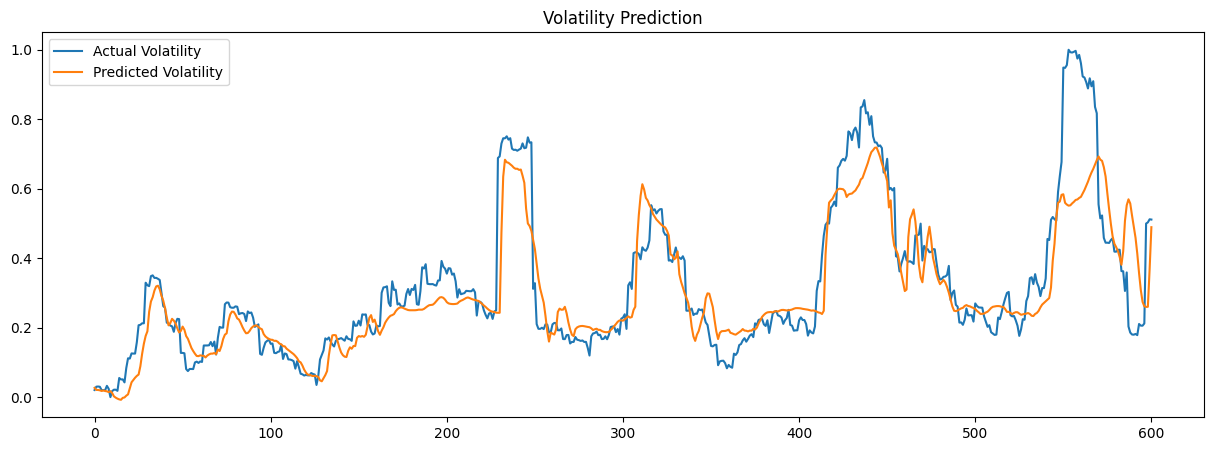

In [77]:
plt.figure(figsize=(15,5))
plt.plot(y_vol_val, label='Actual Volatility')
plt.plot(pred_vol, label='Predicted Volatility')
plt.title('Volatility Prediction')
plt.legend()
plt.show()


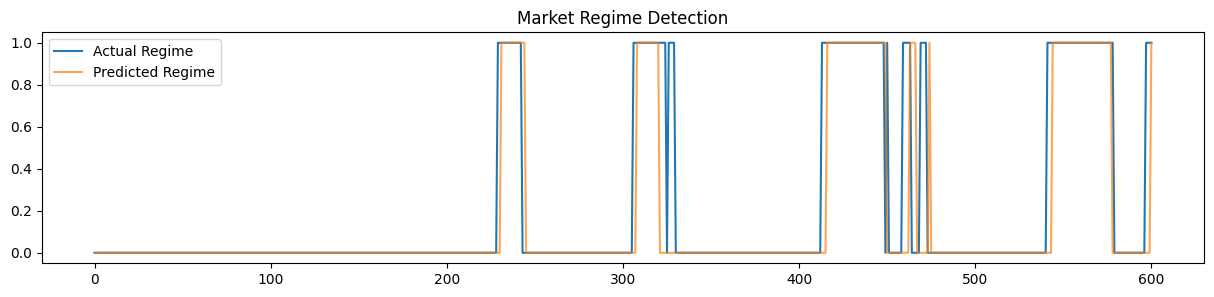

In [78]:
plt.figure(figsize=(15,3))
plt.plot(y_reg_val, label='Actual Regime')
plt.plot(reg_pred, alpha=0.7, label='Predicted Regime')
plt.title('Market Regime Detection')
plt.legend()
plt.show()


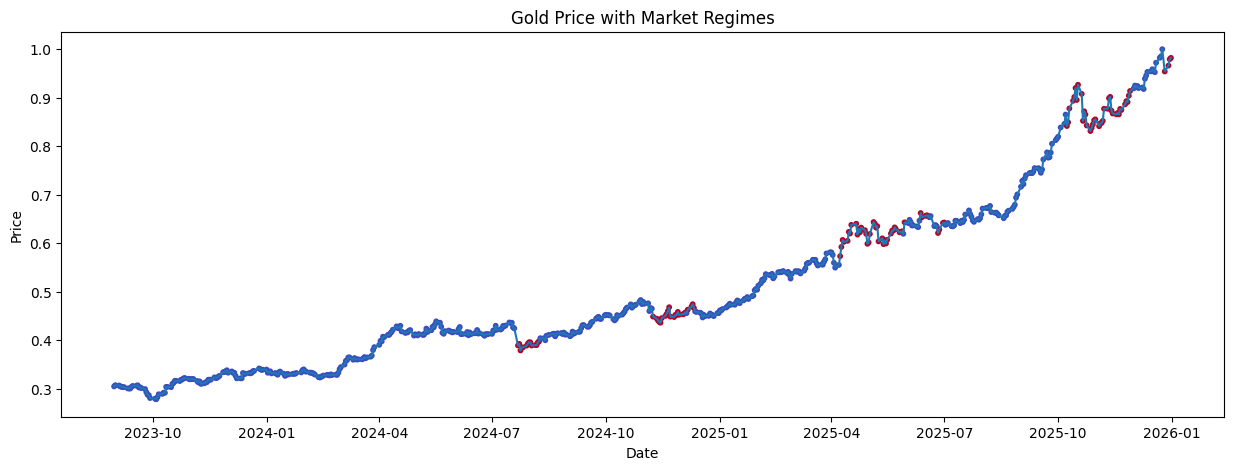

In [80]:
val_dates = df.index[-len(y_price_val):]

plt.figure(figsize=(15,5))
plt.plot(val_dates, y_price_val, label='Price')

plt.scatter(
    val_dates,
    y_price_val,
    c=y_reg_val,
    cmap='coolwarm',
    s=10,
    label='Regime'
)

plt.title('Gold Price with Market Regimes')
plt.xlabel('Date')
plt.ylabel('Price')
plt.show()

In [81]:
recent_mask = val_dates >= '2022-01-01'

print("Recent Period MAE:",
      mean_absolute_error(
          y_price_val[recent_mask],
          pred_price[recent_mask]
      ))


Recent Period MAE: 0.06771133461264627


# ATTENTION-BASED LSTM

In [52]:
import tensorflow as tf
from tensorflow.keras.layers import LSTM, Dense, Input, Attention
from tensorflow.keras.models import Model


In [53]:
inputs = Input(shape=(X_train.shape[1], X_train.shape[2]))

lstm_out = LSTM(64, return_sequences=True)(inputs)
attention = Attention()([lstm_out, lstm_out])
context = tf.keras.layers.Lambda(lambda x: tf.reduce_mean(x, axis=1))(attention)

output = Dense(1)(context)

model = Model(inputs, output)
model.compile(optimizer='adam', loss='mse')

model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 30, 5)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_4 (LSTM)       │ (None, 30, 64)    │     17,920 │ input_layer_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_3         │ (None, 30, 64)    │          0 │ lstm_4[0][0],     │
│ (Attention)         │                   │            │ lstm_4[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, 64)        │          0 │ attention_3[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │         65 │ lambda_1[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 17,985 (70.25 KB)

 Trainable params: 17,985 (70.25 KB)

 Non-trainable params: 0 (0.00 B)

In [54]:
history = model.fit(
    X_train, y_train,
    epochs=25,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)


Epoch 1/25
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.0020 - val_loss: 2.2345e-04
Epoch 2/25
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.2939e-04 - val_loss: 1.9758e-04
Epoch 3/25
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.3907e-04 - val_loss: 1.9395e-04
Epoch 4/25
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.2232e-04 - val_loss: 2.9960e-04
Epoch 5/25
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.2176e-04 - val_loss: 2.0864e-04
Epoch 6/25
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.1028e-04 - val_loss: 1.9059e-04
Epoch 7/25
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 1.0931e-04 - val_loss: 1.8115e-04
Epoch 8/25
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.0223e-04 - val_loss: 1.6691e-04
Epoch 9/25
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.0385e-04 - val_loss: 1.7074e-04
Epoch 10/25
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.1611e-04 - val_loss: 1.8904e-04
Epoch 11/25
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.0364e-04 - 

# QUANTILE REGRESSION

In [55]:
def quantile_loss(q):
    def loss(y_true, y_pred):
        e = y_true - y_pred
        return tf.reduce_mean(tf.maximum(q*e, (q-1)*e))
    return loss


In [56]:
quantile_model = tf.keras.Sequential([
    LSTM(64, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dense(1)
])

quantile_model.compile(
    optimizer='adam',
    loss=quantile_loss(0.9)  # upper bound
)

quantile_model.fit(X_train, y_train, epochs=20, batch_size=32)


Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0312
Epoch 2/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0016
Epoch 3/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0015
Epoch 4/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0016
Epoch 5/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0014
Epoch 6/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0020
Epoch 7/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0012
Epoch 8/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0015
Epoch 9/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0013
Epoch 10/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0011
Epoch 11/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0011
Epoch 12/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0011
Epoch 13/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0011
Epoch 14/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0010
Epoch 15/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0014
Epoch 16/20
77/77 ━━━━━━━━

In [57]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

pred = model.predict(X_test)

mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))

print("MAE:", mae)
print("RMSE:", rmse)


20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
MAE: 0.0513330721799195
RMSE: 0.07292896789875936


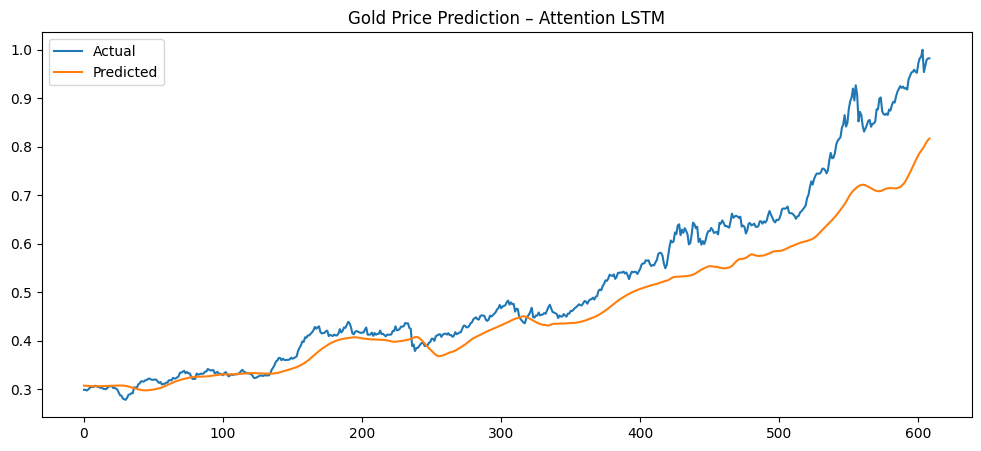

In [58]:
plt.figure(figsize=(12,5))
plt.plot(y_test, label="Actual")
plt.plot(pred, label="Predicted")
plt.legend()
plt.title("Gold Price Prediction – Attention LSTM")
plt.show()
